# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#be3e3a">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Daniel Kolev  |        6160255       |
| Zain Qureshi  |        6143555       |
| Deyan Papazov  |        6191150       |
| Student D  |        XXXXXXX       |

</div>

#### Imports

In [1]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt

#### Loading the data

In [2]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

We will now start with implementing our perceptron. We will create a Perceptron class which will store the functionality of a perceptron. It maintains and updates the weight and bias vectors. During the train proccess it adjusts the vectors to find a better linear fit for the data.

In [30]:
# Put your code for Question 1 here
class Perceptron:
    
    def __init__(self, sizet = 10, rate = 0.01):
        self.weights = np.random.rand((sizet))
        self.bias = np.random.rand()
        self.alpha = rate
    
    def step(self, z):
        return 1 if z >= 0 else 0
    
    def predict(self,input_features):
        return np.dot(self.weights, input_features.T) + self.bias
    
    def loss(self, prediction, label):
        return label - prediction
    
    def train(self, train_data, train_labels, epochs = 100):
        error_history = []
        for e in range(epochs):
            total_error = 0
            for (row,actual) in zip(train_data,train_labels):
                z = self.predict(row)
                prediction = self.step(z)
                loss = self.loss(prediction, actual)
                self.weights = [w + row[j] * self.alpha * loss for j,w in enumerate(self.weights)]
                self.bias = self.bias + self.alpha * loss
                total_error += abs(loss)
            error_history.append(total_error)
        return error_history


* We have added error_history to the train function to ensure that at the end of the train we have the errors after each epoch which will helps us know if we are using too much, or not enought epochs.

* We will test our implementation on a simple 2d array. We will plot the numbers of errors per epoch and the the accuracy. The number of errors will show the errors when we are changing the weight. This means that for linearly seperable it should go to 0 but for a data set which is not linearly seperable it should go to the max number of entries to ensure that the weights are in a dead zone and that there is no more point of epochs.

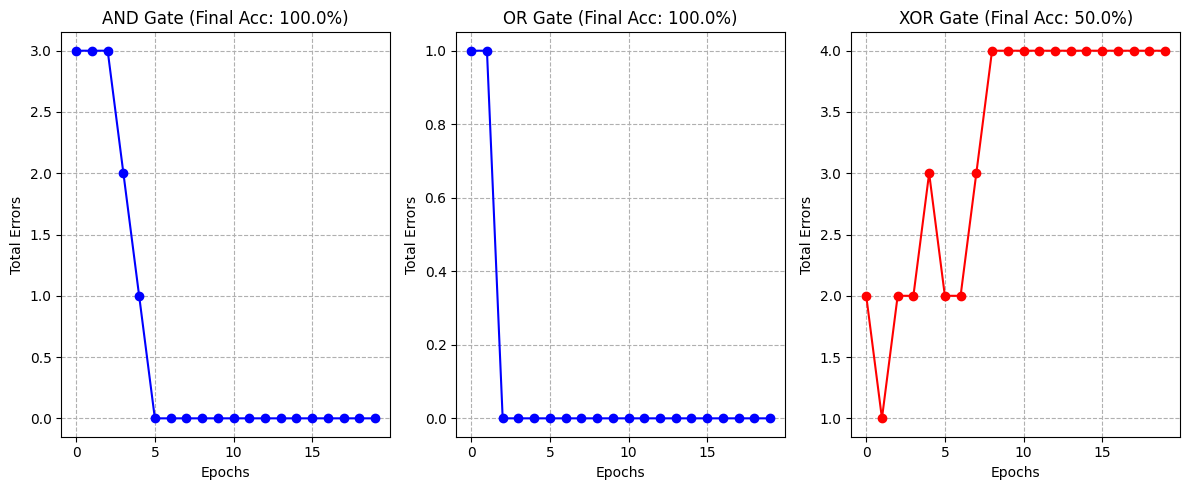

In [34]:
def accuracy(predictions, labels):
    return np.mean(np.where(predictions == labels, 1, 0)) * 100

X = np.array([[0,0], [0,1], [1,0], [1,1]])
gates = {
    "AND": np.array([0, 0, 0, 1]),
    "OR":  np.array([0, 1, 1, 1]),
    "XOR": np.array([0, 1, 1, 0])
}


plt.figure(figsize=(12, 5))

for i, (name, labels) in enumerate(gates.items()):
    # Initialize perceptron with size=2 (for 2 input features)
    model = Perceptron(sizet = 2, rate = 0.1)
    # Train and get the error history
    errors = model.train(X, labels, epochs=20)
    final_preds = np.array([model.step(model.predict(row)) for row in X])
    acc = accuracy(final_preds, labels)
    
    plt.subplot(1, 3, i+1)
    plt.plot(range(len(errors)), errors, marker='o', color='blue' if name != "XOR" else 'red')
    plt.title(f"{name} Gate (Final Acc: {acc}%)")
    plt.xlabel("Epochs")
    plt.ylabel("Total Errors")
    plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

The perceptron achieves 100% accuracy on AND and OR gates because they are linearly separable, allowing the model to find a perfect dividing line between classes.  In contrast, the XOR gate results in 4 total errors and 50% accuracy because it is not linearly separable, meaning no single straight line can correctly classify all four points simultaneously.

#### Question 2

We will need 10 input neurons. This is because the input neurons equals the features of the input. We are given that we want to transform a 10 feature input so we will need 10 neurons. Each specific feature is mapped to a neuron.

#### Question 3

We will need 7 output neurons. This is because the number of output neurons is equal to the number of output classes to which we classify the input. In our case we want to classify the input into 1 out of 7 classes, so we need 7 output neurons.


#### Question 4

For the initial design, the network will use one hidden layer with 10 neurons. This is a solid starting point because a single hidden layer can handle most basic classification tasks without making the math too complicated. I chose 10 neurons to match the number of input features, which gives the model enough neurons to find patterns without overcomplicating things.

#### Question 5

For the hidden layer I will use Sigmoid because it maps the input values to a range between 0 and 1, which helps the network handle non-linear patterns like the ones we saw in the XOR problem. On the other hand, I will use Softmax for the output layer since we have to classify products into 7 different categories, Softmax is the best choice for the final layer. It turns the raw numbers from the neurons into probabilities that add up to 100%, making it easy to see which class the robot thinks the product belongs to.

#### Question 6
This is the diagram for question 6. We have drawn the arros only for 1 input neuron and only for 1 hidden neuron. This is to enchance readibility. In the real neuron netwokr each input perceptron will be connected to each hidden perceptron with weith 1 to 10. Each hidden perceptron will be connected to each output perceptron with value bias1 to 7


<img src="../042cc58e-1.png" alt="Neural Network Schematic" width="500"/>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [4]:
class Linear:
    def __init__(self, in_features, out_features):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
        """

        self.weight = ...
        self.bias = ...

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """

        pass
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
       
        pass

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [5]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """

        pass
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        pass

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [6]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        
        pass
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        pass
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        pass

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [7]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """

    pass

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [8]:
def train(net, inputs, labels, criterion, lr):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    
    pass

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>